Saved: /global/homes/y/yuejian/project/MLFF-distill/Figure_draw/density_vs_temp_0p5M_NaPF6_LiPF6_sim_vs_exp.png


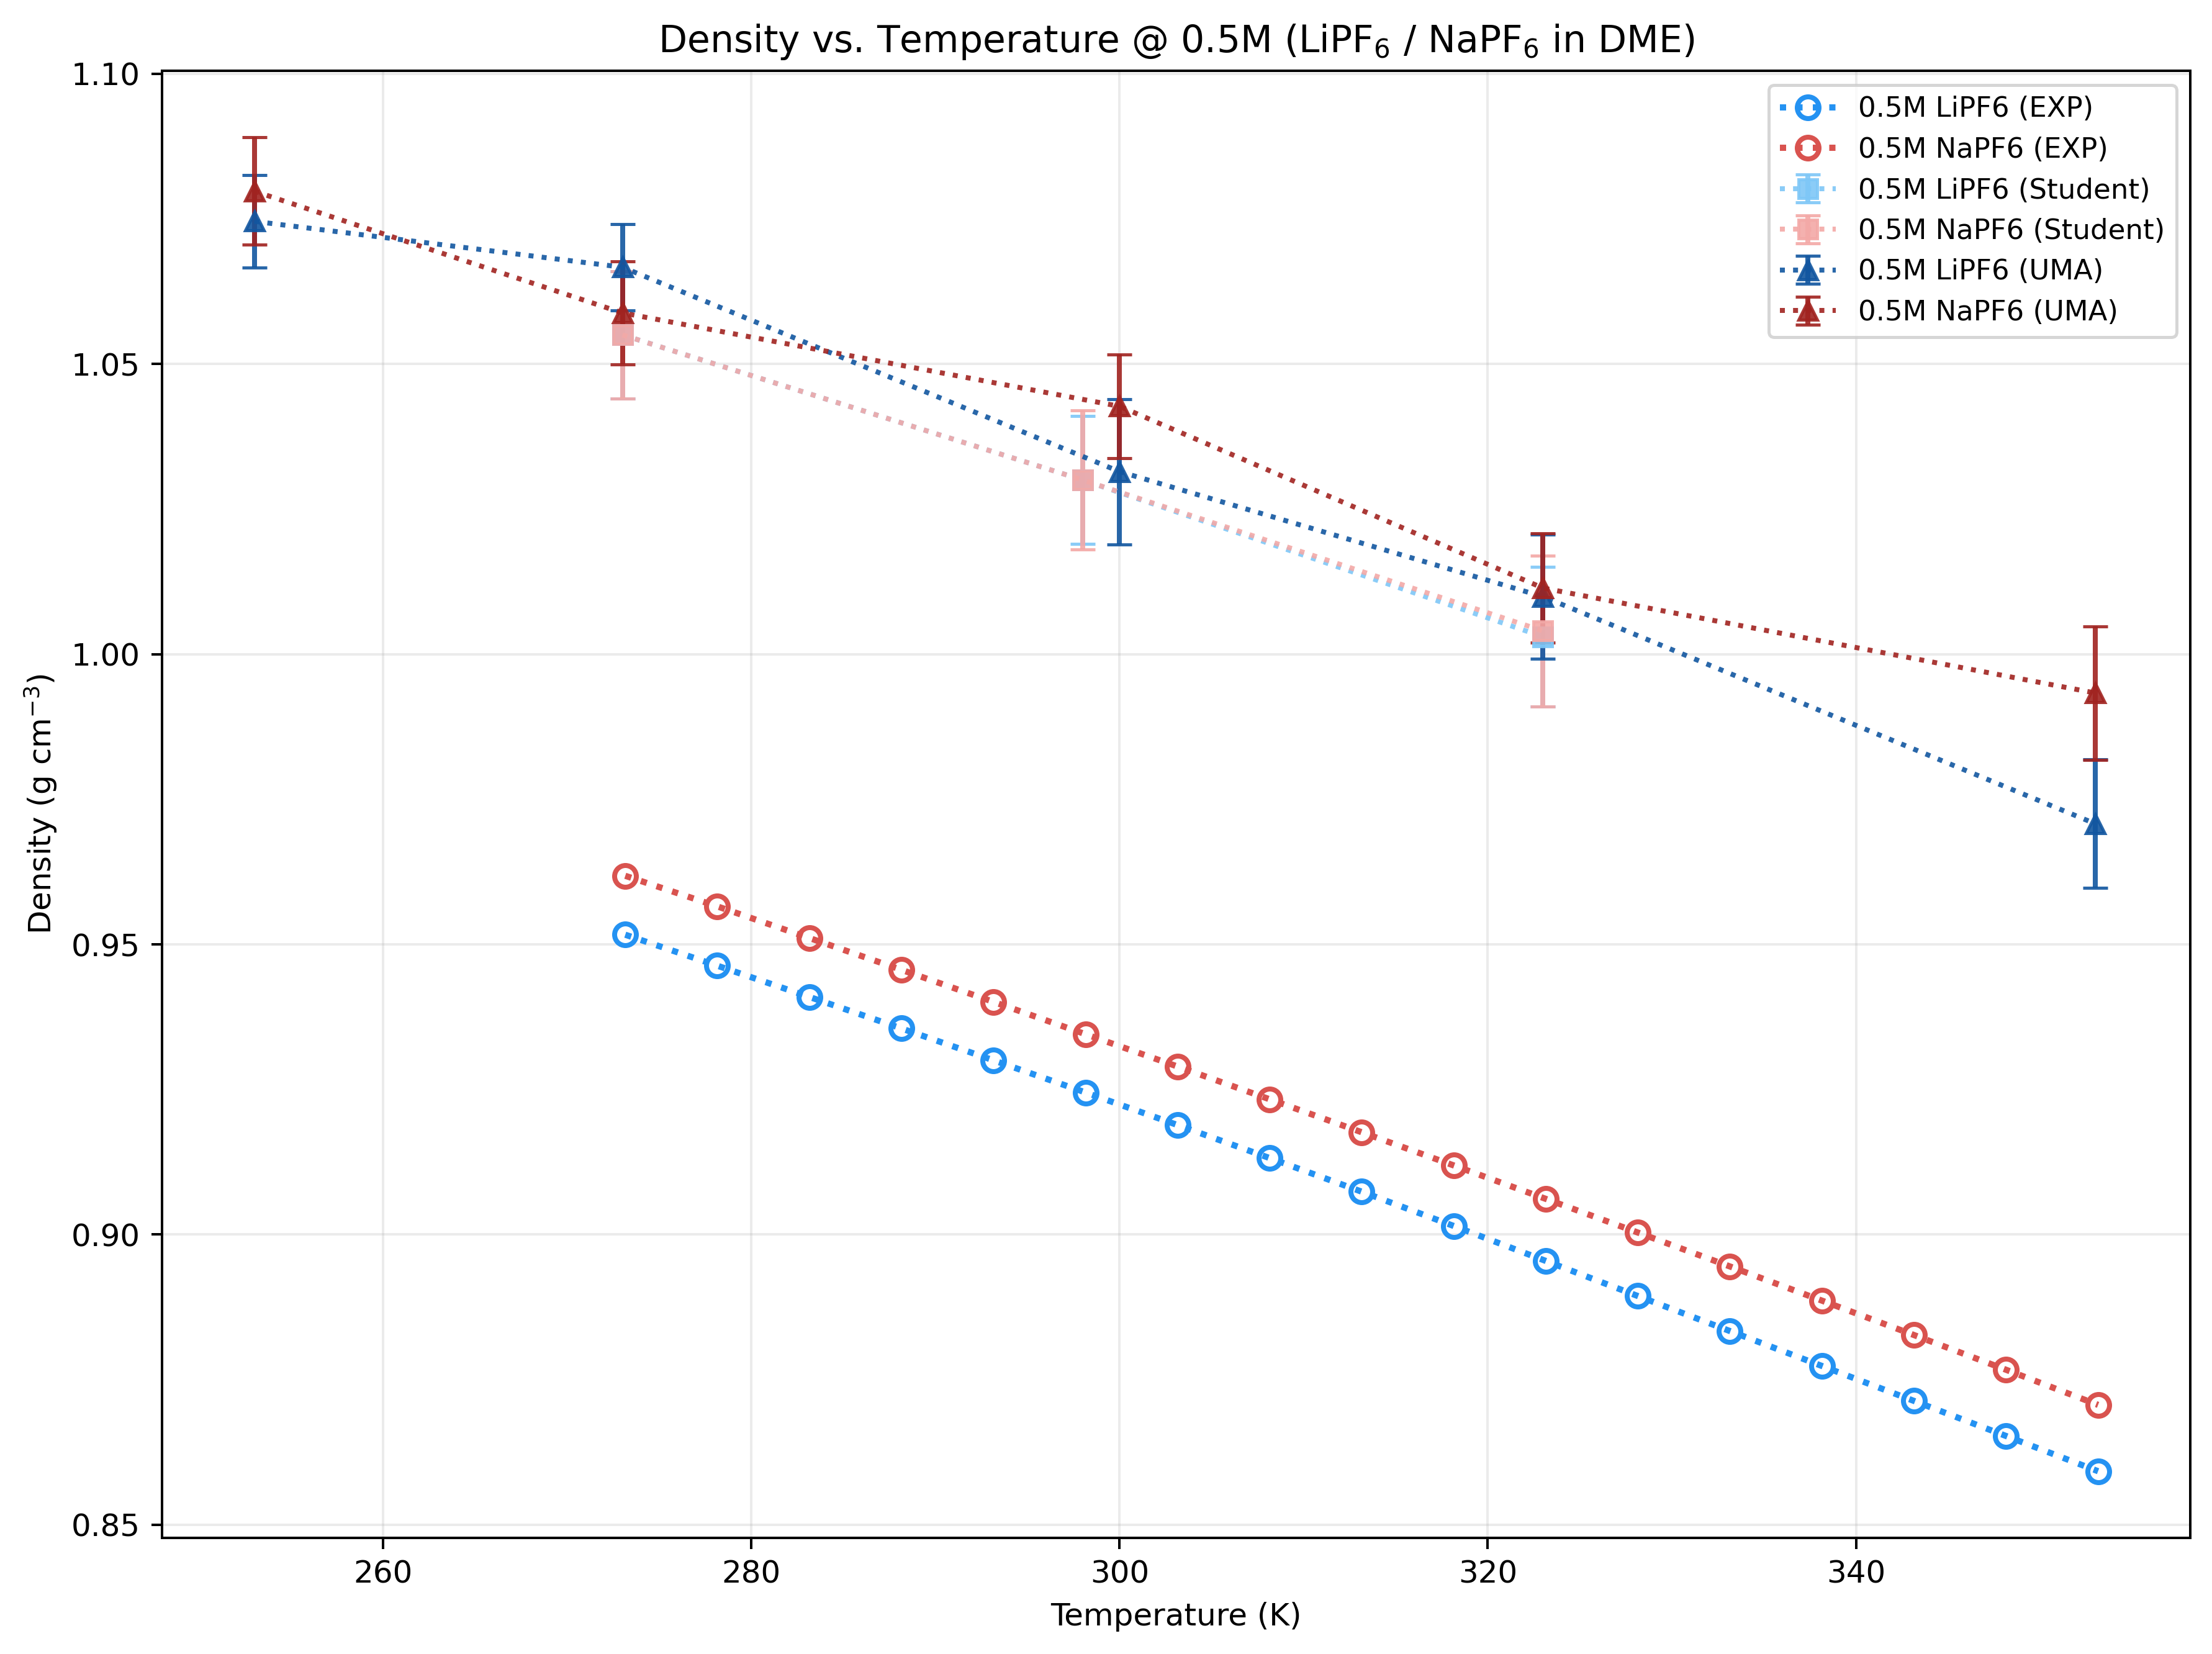

In [1]:
# %%
# Jupyter Notebook version of density vs temperature plotting code
# for 0.5M LiPF6 / NaPF6 in DME (EXP, UMA, Student models)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set default paths (edit as needed for your environment)
repo_root = Path("/global/homes/y/yuejian/project/MLFF-distill")
default_data_dir = repo_root / "yuejian/electrolyte_application/ablate_distillation/observables/data_for_plotting"

exp_csv = default_data_dir / "density_vs_temperature_0p5M_combined_with_errors_exp.csv"
student_csv = default_data_dir / "density_vs_temperature_0p5M_combined_with_errors_student_model.csv"
uma_csv = default_data_dir / "density_vs_temperature_0p5M_combined_with_errors_uma.csv"
out_png = repo_root / "Figure_draw/density_vs_temp_0p5M_NaPF6_LiPF6_sim_vs_exp.png"

# %%
def load_exp_wide_csv(path):
    """
    Expected columns:
      - T_K
      - LiPF6_DME_0.5M
      - NaPF6_DME_0.5M
    Returns long-form with columns: system, temperature, density
    """
    df = pd.read_csv(path)
    if "T_K" not in df.columns:
        raise ValueError(f"EXP CSV missing 'T_K' column: {path}")

    mapping = {
        "LiPF6_DME_0.5M": "0.5M LiPF6",
        "NaPF6_DME_0.5M": "0.5M NaPF6",
    }
    missing = [c for c in mapping.keys() if c not in df.columns]
    if missing:
        raise ValueError(f"EXP CSV missing columns {missing}: {path}")

    long = (
        df.melt(
            id_vars=["T_K"],
            value_vars=list(mapping.keys()),
            var_name="system_raw",
            value_name="density",
        )
        .rename(columns={"T_K": "temperature"})
        .assign(system=lambda d: d["system_raw"].map(mapping))
        .drop(columns=["system_raw"])
        .dropna(subset=["temperature", "density", "system"])
        .sort_values(["system", "temperature"])
        .reset_index(drop=True)
    )
    return long[["system", "temperature", "density"]]

# %%
def load_sim_csv(path):
    """
    Expected columns:
      - system
      - temperature (K)
      - density (g/cm^3)
      - std_dev (g/cm^3)
    """
    df = pd.read_csv(path)
    required = {"system", "temperature", "density", "std_dev"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"SIM CSV missing columns {missing}: {path}")
    df = df.copy()
    df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
    df["density"] = pd.to_numeric(df["density"], errors="coerce")
    df["std_dev"] = pd.to_numeric(df["std_dev"], errors="coerce")
    df = df.dropna(subset=["system", "temperature", "density", "std_dev"])
    return df.sort_values(["system", "temperature"]).reset_index(drop=True)

# %%
# Load dataframes (cell by cell edit paths if testing interactively)
exp_df = load_exp_wide_csv(exp_csv)
student_df = load_sim_csv(student_csv)
uma_df = load_sim_csv(uma_csv)

# %%
def make_plot(exp_df, uma_df, student_df, outpath=None):
    systems = ["0.5M LiPF6", "0.5M NaPF6"]

    # Give different colors for system (salt) and for data "source"
    # Use lighter colors for Student and brighter for UMA, keep EXP same as before
    system_colors = {
        "0.5M LiPF6": "#2492f2",   # reference blue (for EXP)
        "0.5M NaPF6": "#d9534f",   # reference red (for EXP)
    }
    # Assign different shades per source type for each system
    source_colors = {
        # "system": { "EXP": ..., "Student": ..., "UMA": ... }
        "0.5M LiPF6": {
            "EXP": "#2492f2",             # blue (bright)
            "Student": "#7ec7f7",         # lighter blue (for Student)
            "UMA": "#1256a0",             # dark blue (for UMA)
        },
        "0.5M NaPF6": {
            "EXP": "#d9534f",             # red (bright)
            "Student": "#f3a9a7",         # lighter red (for Student)
            "UMA": "#a12320",             # dark red (for UMA)
        }
    }
    source_marker = {
        "EXP": "o",
        "Student": "s",
        "UMA": "^",
    }

    # --- INCREASED RESOLUTION AND FIGURE SIZE ---
    fig, ax = plt.subplots(figsize=(10, 7.5), dpi=360)  # higher-res: bigger fig + higher dpi

    # Student (dotted)
    for sys in systems:
        d = student_df[student_df["system"] == sys]
        if len(d) == 0:
            continue
        ax.errorbar(
            d["temperature"],
            d["density"],
            yerr=d["std_dev"],
            fmt=source_marker["Student"],
            color=source_colors[sys]["Student"],
            linestyle=":",
            linewidth=1.6,
            capsize=4,
            markersize=6,
            alpha=0.9,
            label=f"{sys} (Student)",
        )

    # UMA (dotted)
    for sys in systems:
        d = uma_df[uma_df["system"] == sys]
        if len(d) == 0:
            continue
        ax.errorbar(
            d["temperature"],
            d["density"],
            yerr=d["std_dev"],
            fmt=source_marker["UMA"],
            color=source_colors[sys]["UMA"],
            linestyle=":",
            linewidth=1.6,
            capsize=4,
            markersize=6,
            alpha=0.9,
            label=f"{sys} (UMA)",
        )

    # EXP (dotted, open marker, no error bars)
    for sys in systems:
        d = exp_df[exp_df["system"] == sys]
        if len(d) == 0:
            continue
        ax.plot(
            d["temperature"],
            d["density"],
            marker=source_marker["EXP"],
            linestyle=":",
            linewidth=2.0,
            markersize=7,
            markerfacecolor="none",
            markeredgewidth=1.6,
            color=source_colors[sys]["EXP"],
            alpha=1.0,
            label=f"{sys} (EXP)",
        )

    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel(r"Density (g cm$^{-3}$)")
    ax.set_title(r"Density vs. Temperature @ 0.5M (LiPF$_6$ / NaPF$_6$ in DME)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, ncol=1, frameon=True)

    fig.tight_layout()
    if outpath is not None:
        outpath = Path(outpath)
        outpath.parent.mkdir(parents=True, exist_ok=True)
        # Save with even higher DPI for publication-quality figure
        fig.savefig(outpath, dpi=600, bbox_inches="tight")
        print(f"Saved: {outpath}")
    plt.show()

# %%
# Make figure and show it (and save to file if desired)
make_plot(exp_df=exp_df, uma_df=uma_df, student_df=student_df, outpath=out_png)


In [ ]:
# %%
# Make figure and show it (and save to file if desired)
make_plot(exp_df=exp_df, uma_df=uma_df, student_df=student_df, outpath=out_png)